In [1]:
import sys
from pathlib import Path
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
import seaborn as sns
from scipy.stats import skew, kurtosis, wasserstein_distance
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score

# Ensure project root is in path
PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_utils import DatasetPT
from src.enc_dec_dataset import MomentsEncoderDecoder, PercentileEncoderDecoder, GMCMEncoderDecoder

In [ ]:
DATASET_NAMES = ["BZR", "DHFR", "Mutagenicity", "MUTAG"]
DISCRETE_FEATURES = ["n_nodes", "n_edges"]
CONTINUOUS_FEATURES = [
    "degree_moments_0", "degree_moments_1", "degree_moments_2", "degree_moments_3", 
    "annd_0", "annd_1", "annd_2", "annd_3",
    "eccentricity_0", "eccentricity_1", "eccentricity_2", "eccentricity_3"
]
FEATURES = DISCRETE_FEATURES + CONTINUOUS_FEATURES
IS_DISCRETE = np.array([feat in DISCRETE_FEATURES for feat in FEATURES])
RNG = np.random.default_rng(seed=42)

def load_generation_data() -> pd.DataFrame:
    """Load and preprocess all original datasets and synthetic variants saving all per-graph statistics."""
    rows = []
    original_stats_map = {}

    for dataset_name in DATASET_NAMES:
        # Load original
        orig_pt_path = PROJECT_ROOT / "data" / dataset_name / f"{dataset_name}_original.pt"
        if orig_pt_path.exists():
            dataset_obj = DatasetPT(orig_pt_path)
            per_graph_stats = dataset_obj.metadata.get("per_graph_statistics", [])

            for i, stats in enumerate(per_graph_stats):                
                row = {
                    "dataset": dataset_name,
                    "graph_idx": i,
                    "class_id": dataset_obj[i].y.item(),
                }
                # Flatten the stats dictionary
                for key, value in stats.items():
                    if isinstance(value, (list, np.ndarray)):
                        for idx, val in enumerate(value):
                            row[f"{key}_{idx}"] = val
                    else:
                        row[key] = value
                rows.append(row)
        else:
            print(f"Warning: Original dataset not found at {orig_pt_path}")
                        
    df = pd.DataFrame(rows)
    if "seed" in df.columns:
        df["seed"] = df["seed"].astype("Int64")
    return df

# Load data
df = load_generation_data()
display(df.head(10))

# Initialize Encoder/Decoder with the correct number of classes and discrete info
num_classes = int(df["class_id"].max() + 1)
# ENC_DEC = MomentsEncoderDecoder(num_classes=num_classes, is_discrete=IS_DISCRETE, k=4, rng=RNG)
ENC_DEC = PercentileEncoderDecoder(num_classes=num_classes, is_discrete=IS_DISCRETE, percentile_size=0.1, replicate_correlation=True, rng=RNG)
# ENC_DEC = GMCMEncoderDecoder(num_classes=num_classes, is_discrete=IS_DISCRETE, percentile_size=0.1, n_components=10, rng=RNG)

DATASETS = [d for d in DATASET_NAMES if d in df["dataset"].unique()]

,dataset,graph_idx,class_id,n_nodes,n_edges,modularity,clustering,assortativity,efficiency,diameter,...,degree_moments_2,degree_moments_3,annd_0,annd_1,annd_2,annd_3,eccentricity_0,eccentricity_1,eccentricity_2,eccentricity_3
0,BZR,0,0,30,32,0.584473,0.0,-0.387755,0.305459,10.0,...,-0.086877,1.177793,0.107759,0.107040,0.085386,0.082512,0.301724,0.280172,0.261084,0.246305
1,BZR,1,0,33,35,0.601224,0.0,-0.489362,0.291970,10.0,...,0.060259,1.276020,0.104167,0.100911,0.082031,0.072591,0.284722,0.261719,0.222656,0.242188
2,BZR,2,0,30,32,0.580566,0.0,-0.387755,0.305459,10.0,...,-0.086877,1.177793,0.107759,0.107040,0.085386,0.082512,0.310345,0.271552,0.261084,0.246305
3,BZR,3,0,33,35,0.599184,0.0,-0.489362,0.291970,10.0,...,0.060259,1.276020,0.104167,0.100911,0.082031,0.072591,0.284722,0.261719,0.226562,0.238281
4,BZR,4,0,30,32,0.584473,0.0,-0.387755,0.305459,10.0,...,-0.086877,1.177793,0.107759,0.107040,0.085386,0.082512,0.301724,0.280172,0.261084,0.246305
5,BZR,5,0,33,35,0.598776,0.0,-0.489362,0.291970,10.0,...,0.060259,1.276020,0.104167,0.100911,0.082031,0.072591,0.284722,0.261719,0.222656,0.242188
6,BZR,6,0,30,32,0.584473,0.0,-0.387755,0.305459,10.0,...,-0.086877,1.177793,0.107759,0.107040,0.085386,0.082512,0.310345,0.271552,0.261084,0.246305
7,BZR,7,0,30,32,0.584473,0.0,-0.387755,0.305459,10.0,...,-0.086877,1.177793,0.103448,0.111351,0.085386,0.082512,0.310345,0.271552,0.261084,0.246305
8,BZR,8,0,33,35,0.606939,0.0,-0.489362,0.291970,10.0,...,0.060259,1.276020,0.104167,0.100911,0.082031,0.072591,0.288194,0.257812,0.226562,0.238281
9,BZR,9,0,30,32,0.584473,0.0,-0.387755,0.305459,10.0,...,-0.086877,1.177793,0.107759,0.107040,0.085386,0.082512,0.310345,0.271552,0.261084,0.246305


In [3]:
def encode_and_sample_dataset(df_dataset: pd.DataFrame, dataset_name: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Encodes original statistics and samples synthetic ones for all classes in a dataset."""
    embeddings_rows = []
    samples_list = []
    
    for class_id, group in df_dataset.groupby("class_id"):
        # --- Encode ---
        stat_matrix = group[FEATURES].values
        ENC_DEC.encode_features(stat_matrix, class_id)

        # Save encodings for this class
        emb_row = {"class_id": class_id}
        encoding = ENC_DEC._encodings[class_id]
        for i, feat in enumerate(FEATURES):
            emb_row[feat] = encoding[:, i]
        embeddings_rows.append(emb_row)

        # --- Sample ---
        n_samples = len(group)
        samples_matrix = ENC_DEC.sample_features(n_samples, class_id)
    
        # Save samples for this class
        class_samples_df = pd.DataFrame(samples_matrix, columns=FEATURES)
        class_samples_df["class_id"] = class_id
        class_samples_df[DISCRETE_FEATURES] = class_samples_df[DISCRETE_FEATURES].astype(int)
        samples_list.append(class_samples_df)
        
    # Construct final DataFrames
    df_emb = pd.DataFrame(embeddings_rows)
    df_samples = pd.concat(samples_list, ignore_index=True)
    
    df_emb.insert(0, "dataset", dataset_name)
    df_samples.insert(0, "dataset", dataset_name)
    
    return df_emb, df_samples

dataset_embeddings = []
dataset_samples = []

for dataset_name in DATASETS:
    df_subset = df[df["dataset"] == dataset_name]
    df_emb, df_s = encode_and_sample_dataset(df_subset, dataset_name)
    
    dataset_embeddings.append(df_emb)
    dataset_samples.append(df_s)
    
    print(f"\n--- {dataset_name} ---")
    # Get embedding size for the first class (all classes have same embedding size)
    emb_size = ENC_DEC.get_embedding(df_subset["class_id"].iloc[0]).shape[0]
    print(f"Embedding vector dimension: {emb_size}")
    display(df_emb.head())
    display(df_s.head())

df_embeddings = pd.concat(dataset_embeddings, ignore_index=True)
df_synthetic = pd.concat(dataset_samples, ignore_index=True)


--- BZR ---
Embedding vector dimension: 1354


,dataset,class_id,n_nodes,n_edges,degree_moments_0,degree_moments_1,degree_moments_2,degree_moments_3,annd_0,annd_1,annd_2,annd_3,eccentricity_0,eccentricity_1,eccentricity_2,eccentricity_3
0,BZR,0,"[20.834130040501545, 29.62609208656454, 31.398...","[22.672994445191595, 31.90383558051846, 34.305...","[0.03634085213032581, 0.047342995169082115, 0....","[0.00043596616855421755, 0.000586369830447552,...","[-0.5816581574292549, -0.3780365340285153, -0....","[1.0017793607503729, 1.1777929679484538, 1.239...","[0.06190476190476191, 0.07377027734170591, 0.0...","[0.061224489795918366, 0.07759652271847393, 0....","[0.04804421768707483, 0.05849189570119802, 0.0...","[0.042091836734693876, 0.05067340067340068, 0....","[0.19909502262443438, 0.24025974025974028, 0.2...","[0.2378472222222222, 0.24915824915824913, 0.26...","[0.1753472222222222, 0.20346320346320346, 0.21...","[0.1909722222222222, 0.2159709338280767, 0.225..."
1,BZR,1,"[12.802071568783639, 22.62617408443601, 25.100...","[12.5016607076748, 24.162267467709928, 26.7163...","[0.04408163265306122, 0.050739957716701894, 0....","[0.0004718086214077467, 0.0006673882111134107,...","[-0.6028590428569108, -0.41303411329251727, -0...","[0.7272727272727271, 1.1416590328990475, 1.193...","[0.06382978723404255, 0.07398553827125257, 0.0...","[0.06783746556473828, 0.07716049382716049, 0.0...","[0.053240740740740734, 0.0613107822410148, 0.0...","[0.04701967592592592, 0.05659681227863046, 0.0...","[0.20995670995670995, 0.23783767911674886, 0.2...","[0.20995670995670995, 0.24341503267973857, 0.2...","[0.17099567099567098, 0.20916700013338668, 0.2...","[0.1768707482993197, 0.20313390313390312, 0.22..."


,dataset,n_nodes,n_edges,degree_moments_0,degree_moments_1,degree_moments_2,degree_moments_3,annd_0,annd_1,annd_2,annd_3,eccentricity_0,eccentricity_1,eccentricity_2,eccentricity_3,class_id
0,BZR,33,38,0.069459,0.000834,-0.573627,1.253457,0.092263,0.080381,0.083570,0.077007,0.315977,0.333120,0.242879,0.296519,0
1,BZR,33,36,0.071509,0.000934,-0.563085,1.217087,0.096644,0.088957,0.083110,0.077759,0.316696,0.275413,0.249622,0.296016,0
2,BZR,33,37,0.068632,0.000911,-0.454058,1.285655,0.093113,0.095728,0.078938,0.076232,0.321536,0.284109,0.255951,0.295715,0
3,BZR,35,38,0.066401,0.000931,0.060511,1.318590,0.092559,0.106562,0.073262,0.070781,0.305261,0.254202,0.263078,0.290703,0
4,BZR,31,36,0.083792,0.000966,-0.581422,1.102741,0.100150,0.088986,0.108464,0.077279,0.344051,0.283822,0.261642,0.315388,0



--- DHFR ---
Embedding vector dimension: 1354


,dataset,class_id,n_nodes,n_edges,degree_moments_0,degree_moments_1,degree_moments_2,degree_moments_3,annd_0,annd_1,annd_2,annd_3,eccentricity_0,eccentricity_1,eccentricity_2,eccentricity_3
0,DHFR,0,"[19.67723550124927, 35.89319283645484, 38.1346...","[20.540253739939924, 38.011203659849116, 39.84...","[0.031207598371777476, 0.038383838383838395, 0...","[0.00027059187898348743, 0.0004078427453391558...","[-0.41303411329251816, -0.06532755748039175, 0...","[0.9648786670330307, 1.2999617961309402, 1.359...","[0.05248868778280543, 0.06364532019704433, 0.0...","[0.0493212669683258, 0.06256738544474394, 0.06...","[0.03974358974358975, 0.048137397194000967, 0....","[0.031486742424242424, 0.04140982953413586, 0....","[0.225, 0.25, 0.2603441295546559, 0.2708333333...","[0.21587301587301586, 0.26245039682539684, 0.2...","[0.1926829268292683, 0.22922714078374454, 0.23...","[0.20243902439024392, 0.22745833333333332, 0.2..."
1,DHFR,1,"[19.620110630101383, 29.77948737357019, 33.389...","[20.571304534184847, 31.2792699435748, 35.2078...","[0.029376257545271626, 0.0396103896103896, 0.0...","[0.00025804727762955993, 0.0004709158289142317...","[-0.4260686100651611, -0.15406294099485812, -0...","[0.9648786670330307, 1.246549629527584, 1.2995...","[0.05141129032258065, 0.06873315363881402, 0.0...","[0.05004389815627744, 0.06593406593406594, 0.0...","[0.03981481481481482, 0.051082251082251076, 0....","[0.029271708683473393, 0.04148524431543299, 0....","[0.1948051948051948, 0.25, 0.26406926406926406...","[0.2, 0.2533333333333333, 0.26773049645390073,...","[0.17042606516290726, 0.21893491124260356, 0.2...","[0.1829573934837093, 0.22597402597402597, 0.23..."


...

,dataset,class_id,n_nodes,n_edges,degree_moments_0,degree_moments_1,degree_moments_2,degree_moments_3,annd_0,annd_1,annd_2,annd_3,eccentricity_0,eccentricity_1,eccentricity_2,eccentricity_3
0,Mutagenicity,0,"[3.6337864255938555, 15.202473240703203, 18.72...","[3.1938593342090016, 15.090966193119078, 18.59...","[0.00154851774095085, 0.051219512195121955, 0....","[7.73189833078082e-06, 0.0007409779891738936, ...","[-0.6442352540027577, -0.3639529426398315, -0....","[0.6363636363636367, 0.9072733392993487, 1.051...","[0.007759562841530054, 0.08153890160183067, 0....","[0.006994535519125683, 0.07946127946127945, 0....","[0.006484517304189436, 0.06581196581196581, 0....","[0.006083788706739528, 0.056839703856749316, 0...","[0.07683060109289618, 0.2504756871035941, 0.27...","[0.07234972677595629, 0.23731924360400447, 0.2...","[0.0774863387978142, 0.2125595238095238, 0.230...","[0.0760655737704918, 0.2126984126984127, 0.235..."
1,Mutagenicity,1,"[5.424650219658463, 13.085997987627056, 16.195...","[3.980559890798918, 12.6179174148956, 16.00120...","[0.0011529238147943183, 0.03734968734968735, 0...","[5.072819591162029e-06, 0.0005047244787478602,...","[-0.47590578526816923, -1.3901040008935916e-15...","[0.5555555555555549, 0.9482132774058247, 1.225...","[0.006634615384615384, 0.06552498048399688, 0....","[0.006009615384615385, 0.06557909303810944, 0....","[0.005913461538461539, 0.054157179720704315, 0...","[0.004740918803418804, 0.04344949921872999, 0....","[0.06586538461538462, 0.2179464285714286, 0.25...","[0.06509615384615385, 0.2300311147186147, 0.26...","[0.06134615384615384, 0.19381461675579323, 0.2...","[0.06009615384615385, 0.19991018910397249, 0.2..."


,dataset,n_nodes,n_edges,degree_moments_0,degree_moments_1,degree_moments_2,degree_moments_3,annd_0,annd_1,annd_2,annd_3,eccentricity_0,eccentricity_1,eccentricity_2,eccentricity_3,class_id
0,Mutagenicity,21,23,0.099121,0.002571,0.210236,1.375815,0.151655,0.150505,0.111963,0.118438,0.369836,0.373846,0.299950,0.313416,0
1,Mutagenicity,22,23,0.106087,0.002333,-0.027878,1.254895,0.147198,0.161738,0.118789,0.111906,0.377452,0.373420,0.271555,0.346970,0
2,Mutagenicity,27,29,0.078197,0.001699,0.373934,1.598037,0.131192,0.117212,0.100067,0.085254,0.390040,0.317059,0.287750,0.306668,0
3,Mutagenicity,22,22,0.089343,0.002647,0.517382,1.525129,0.149516,0.158607,0.128383,0.093349,0.397503,0.383069,0.308513,0.329802,0
4,Mutagenicity,22,23,0.096826,0.002854,0.366206,1.469008,0.164107,0.174107,0.111956,0.118910,0.411092,0.393388,0.295868,0.368582,0



--- MUTAG ---
Embedding vector dimension: 1354


,dataset,class_id,n_nodes,n_edges,degree_moments_0,degree_moments_1,degree_moments_2,degree_moments_3,annd_0,annd_1,annd_2,annd_3,eccentricity_0,eccentricity_1,eccentricity_2,eccentricity_3
0,MUTAG,0,"[9.618130850279075, 10.70718672945398, 11.2505...","[9.70101614867756, 10.89927843789411, 11.35637...","[0.09057971014492754, 0.1200378396972824, 0.14...","[0.0012181181012349844, 0.0018514927670052325,...","[-0.4120344771497982, -0.30657262901228804, -0...","[0.8825757575757587, 1.125, 1.2272727272727286...","[0.13043478260869565, 0.15964912280701754, 0.1...","[0.11594202898550723, 0.15, 0.1583333333333333...","[0.09903381642512077, 0.13427083333333337, 0.1...","[0.09206349206349206, 0.11925925925925927, 0.1...","[0.391304347826087, 0.43846153846153846, 0.458...","[0.3115942028985507, 0.37007407407407406, 0.38...","[0.2826086956521739, 0.33403508771929824, 0.35...","[0.2971014492753623, 0.3333333333333333, 0.35,..."
1,MUTAG,1,"[11.636027445220906, 15.117397836892547, 16.89...","[11.537160661819357, 16.777474127928915, 18.74...","[0.08201058201058202, 0.09333333333333332, 0.1...","[0.0005844108408210973, 0.0008280085612960675,...","[-0.7259810173138147, -0.5530660158545608, -0....","[1.058181818181818, 1.4739220226547336, 1.7918...","[0.10164835164835165, 0.1146103896103896, 0.12...","[0.09259259259259259, 0.1076388888888889, 0.11...","[0.09706959706959704, 0.10862977602108036, 0.1...","[0.07936507936507935, 0.09644444444444444, 0.1...","[0.3131868131868132, 0.3485194805194805, 0.368...","[0.28, 0.30292640692640693, 0.3263157894736842...","[0.2222222222222222, 0.26395534290271133, 0.28...","[0.2371794871794872, 0.2679365079365079, 0.285..."


,dataset,n_nodes,n_edges,degree_moments_0,degree_moments_1,degree_moments_2,degree_moments_3,annd_0,annd_1,annd_2,annd_3,eccentricity_0,eccentricity_1,eccentricity_2,eccentricity_3,class_id
0,MUTAG,13,15,0.174945,0.003542,-0.389010,1.822149,0.224386,0.192844,0.184399,0.187118,0.463874,0.437702,0.326200,0.353226,0
1,MUTAG,15,15,0.164277,0.002639,-0.166226,2.255004,0.205004,0.162331,0.199952,0.162837,0.465651,0.433333,0.335915,0.348957,0
2,MUTAG,16,17,0.148137,0.002113,-0.258724,2.208231,0.166485,0.166746,0.174717,0.153682,0.452484,0.402393,0.360906,0.341905,0
3,MUTAG,13,15,0.179487,0.003148,-0.229176,2.226467,0.225609,0.169036,0.207410,0.176826,0.456846,0.467793,0.332335,0.386813,0
4,MUTAG,14,16,0.156391,0.002711,-0.369690,2.079597,0.195842,0.181504,0.170505,0.174479,0.498189,0.411840,0.359794,0.347982,0


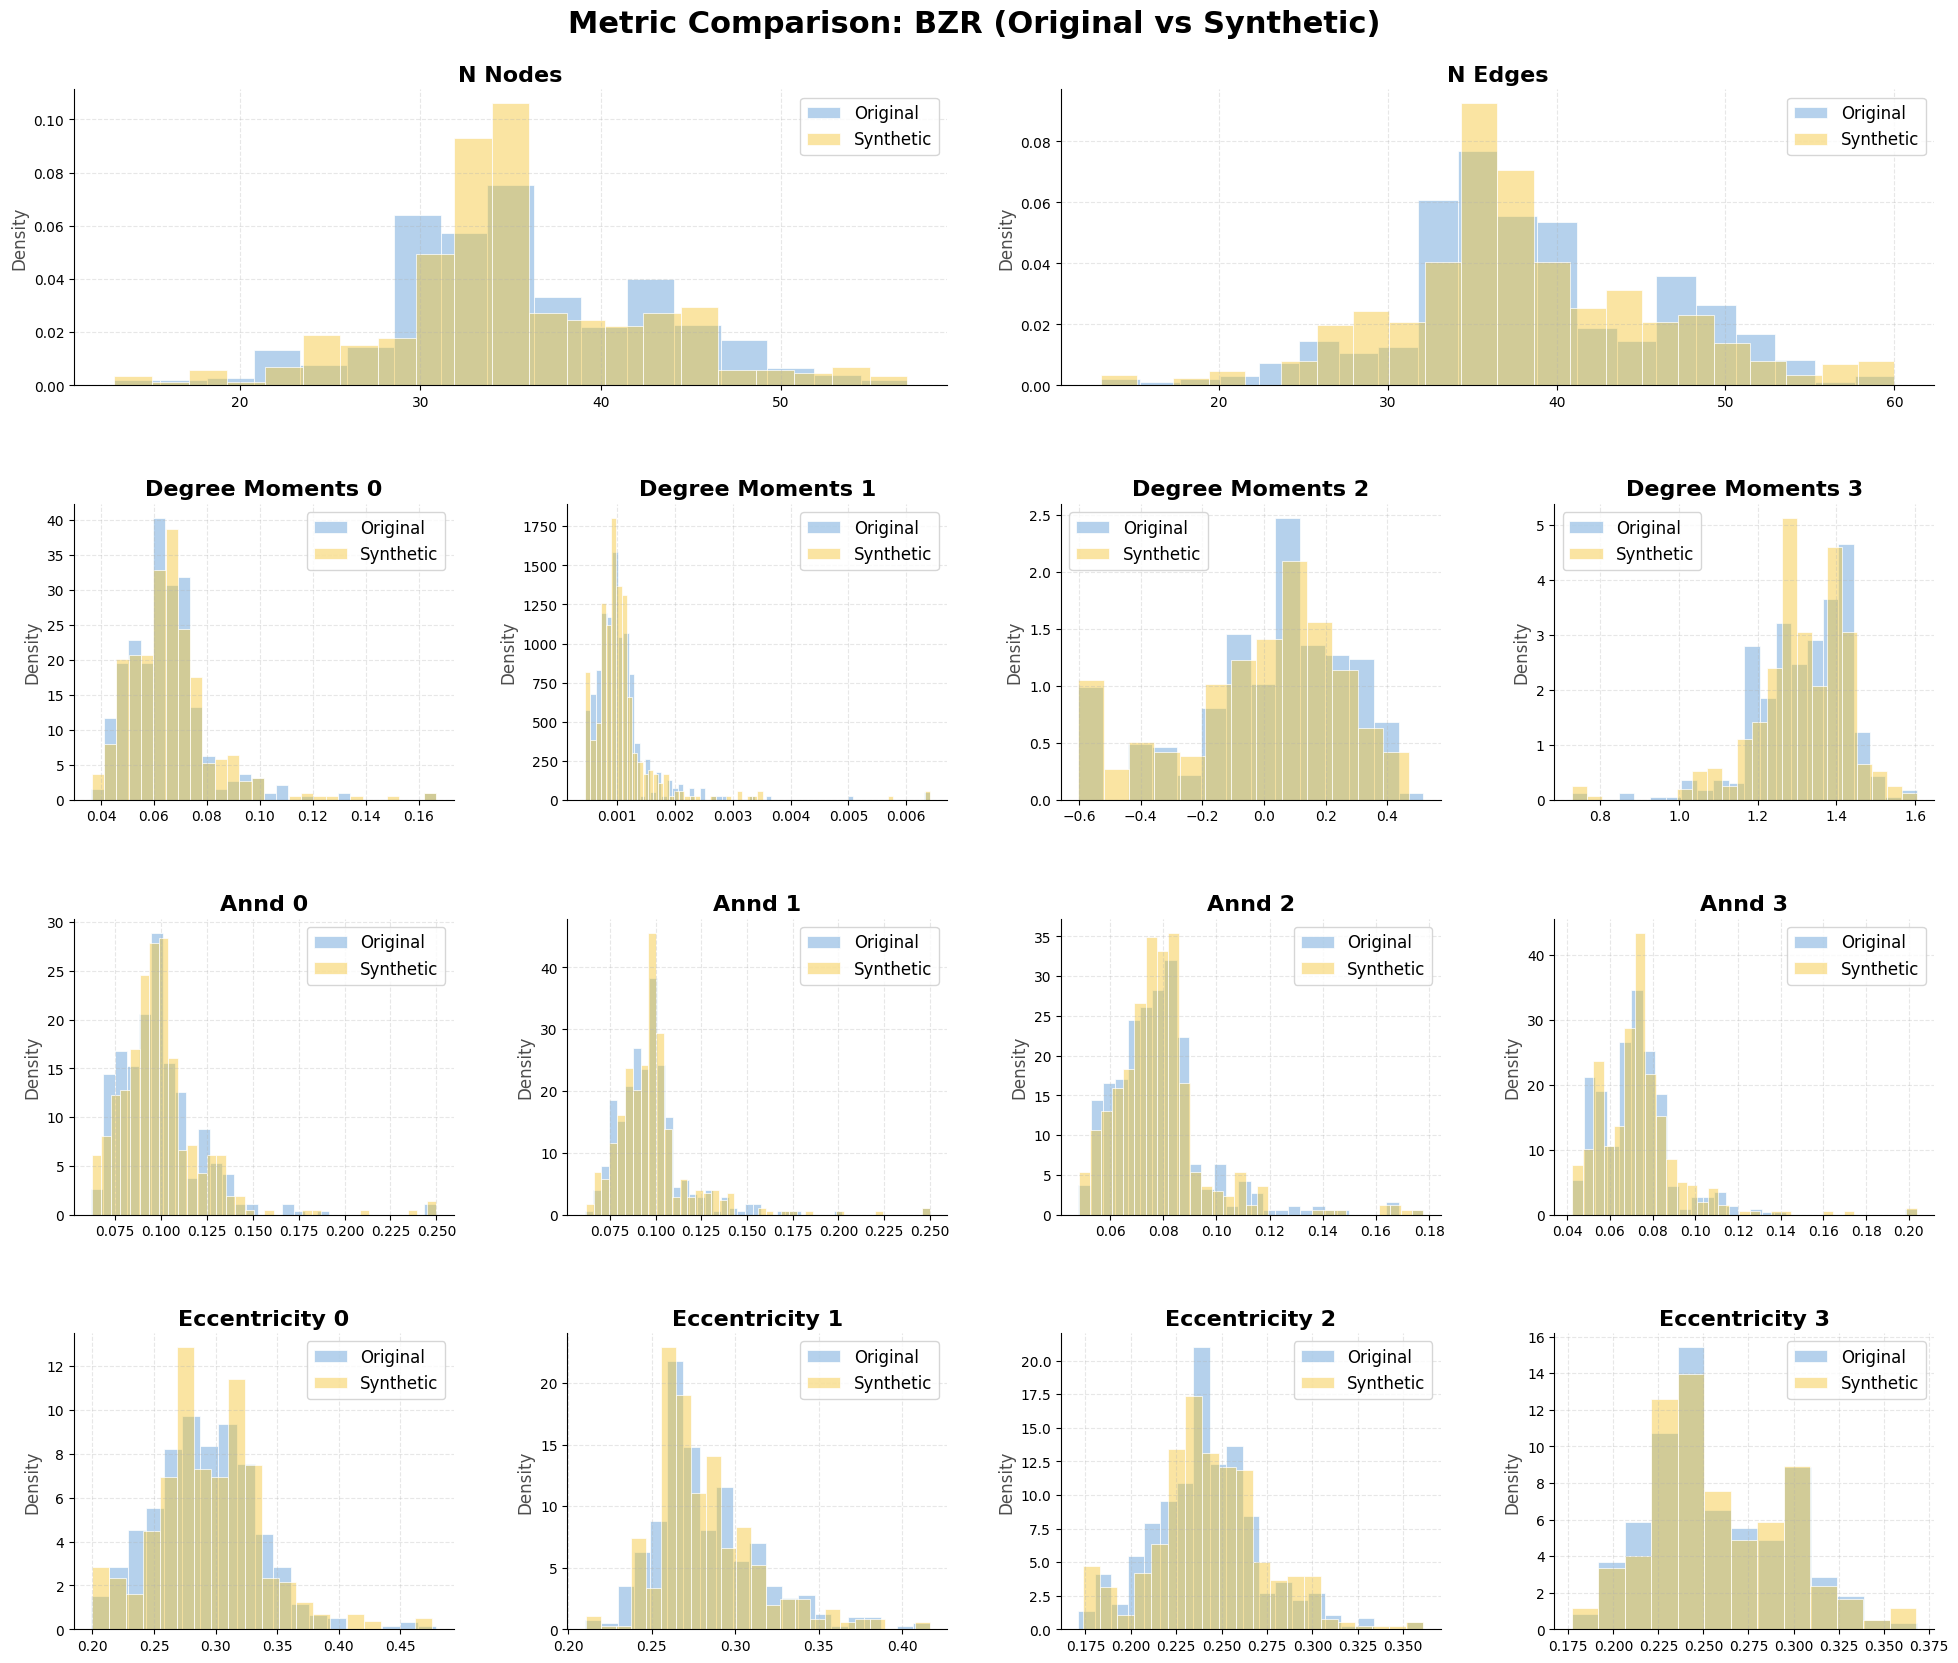

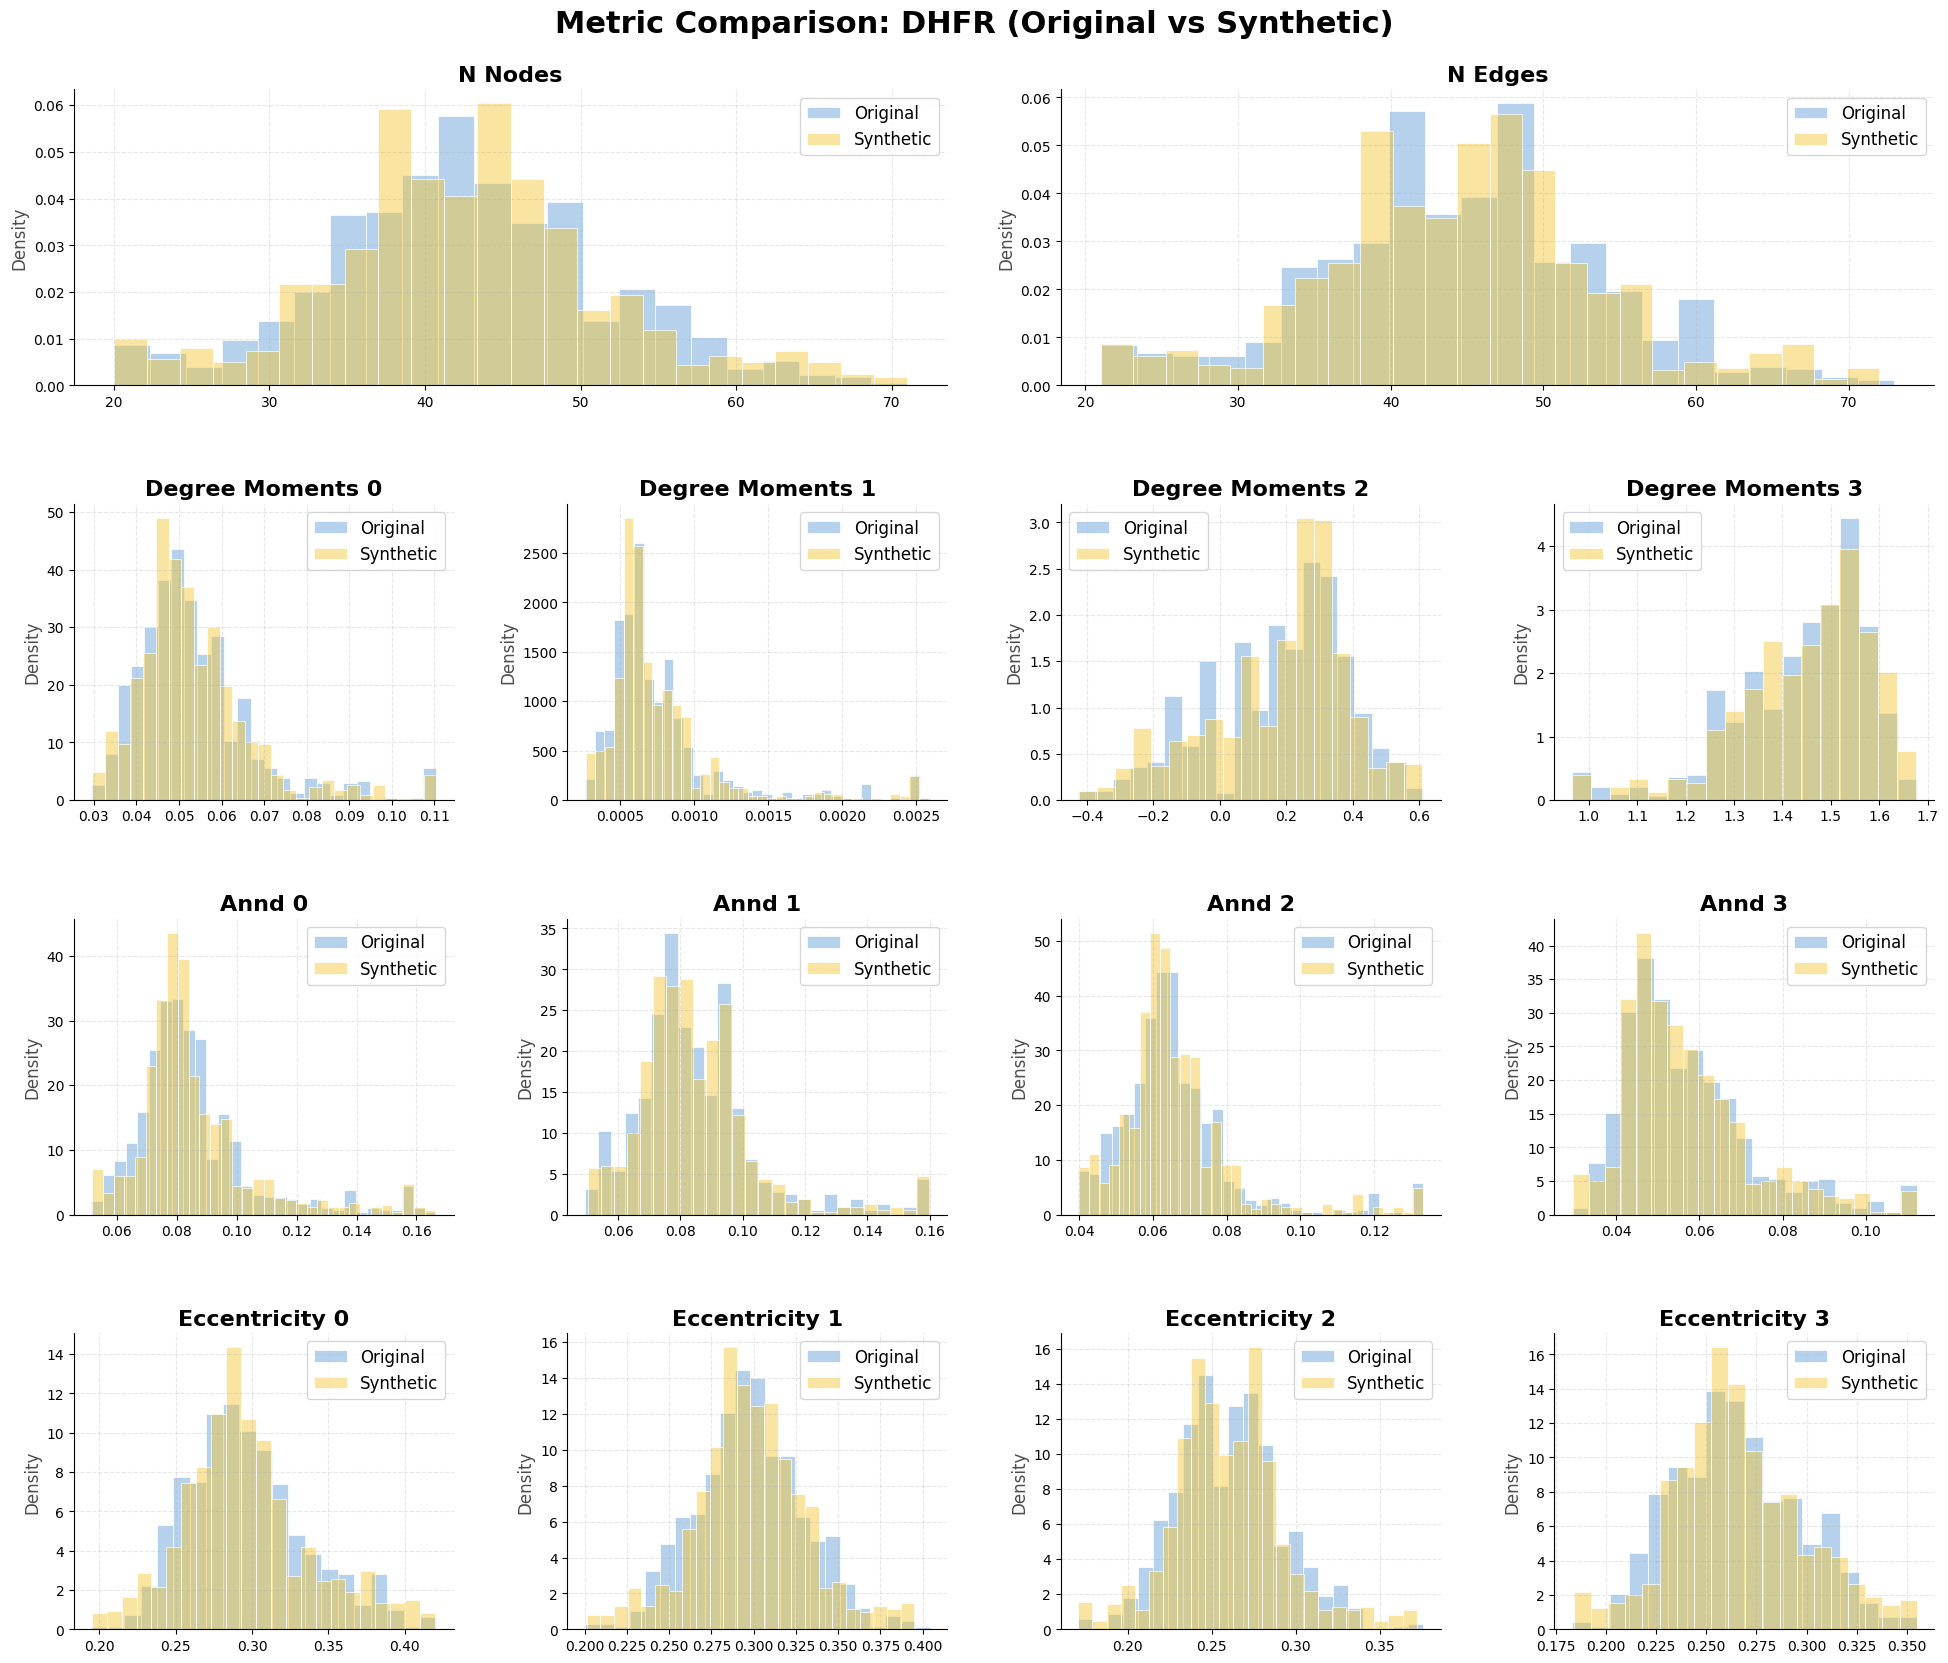

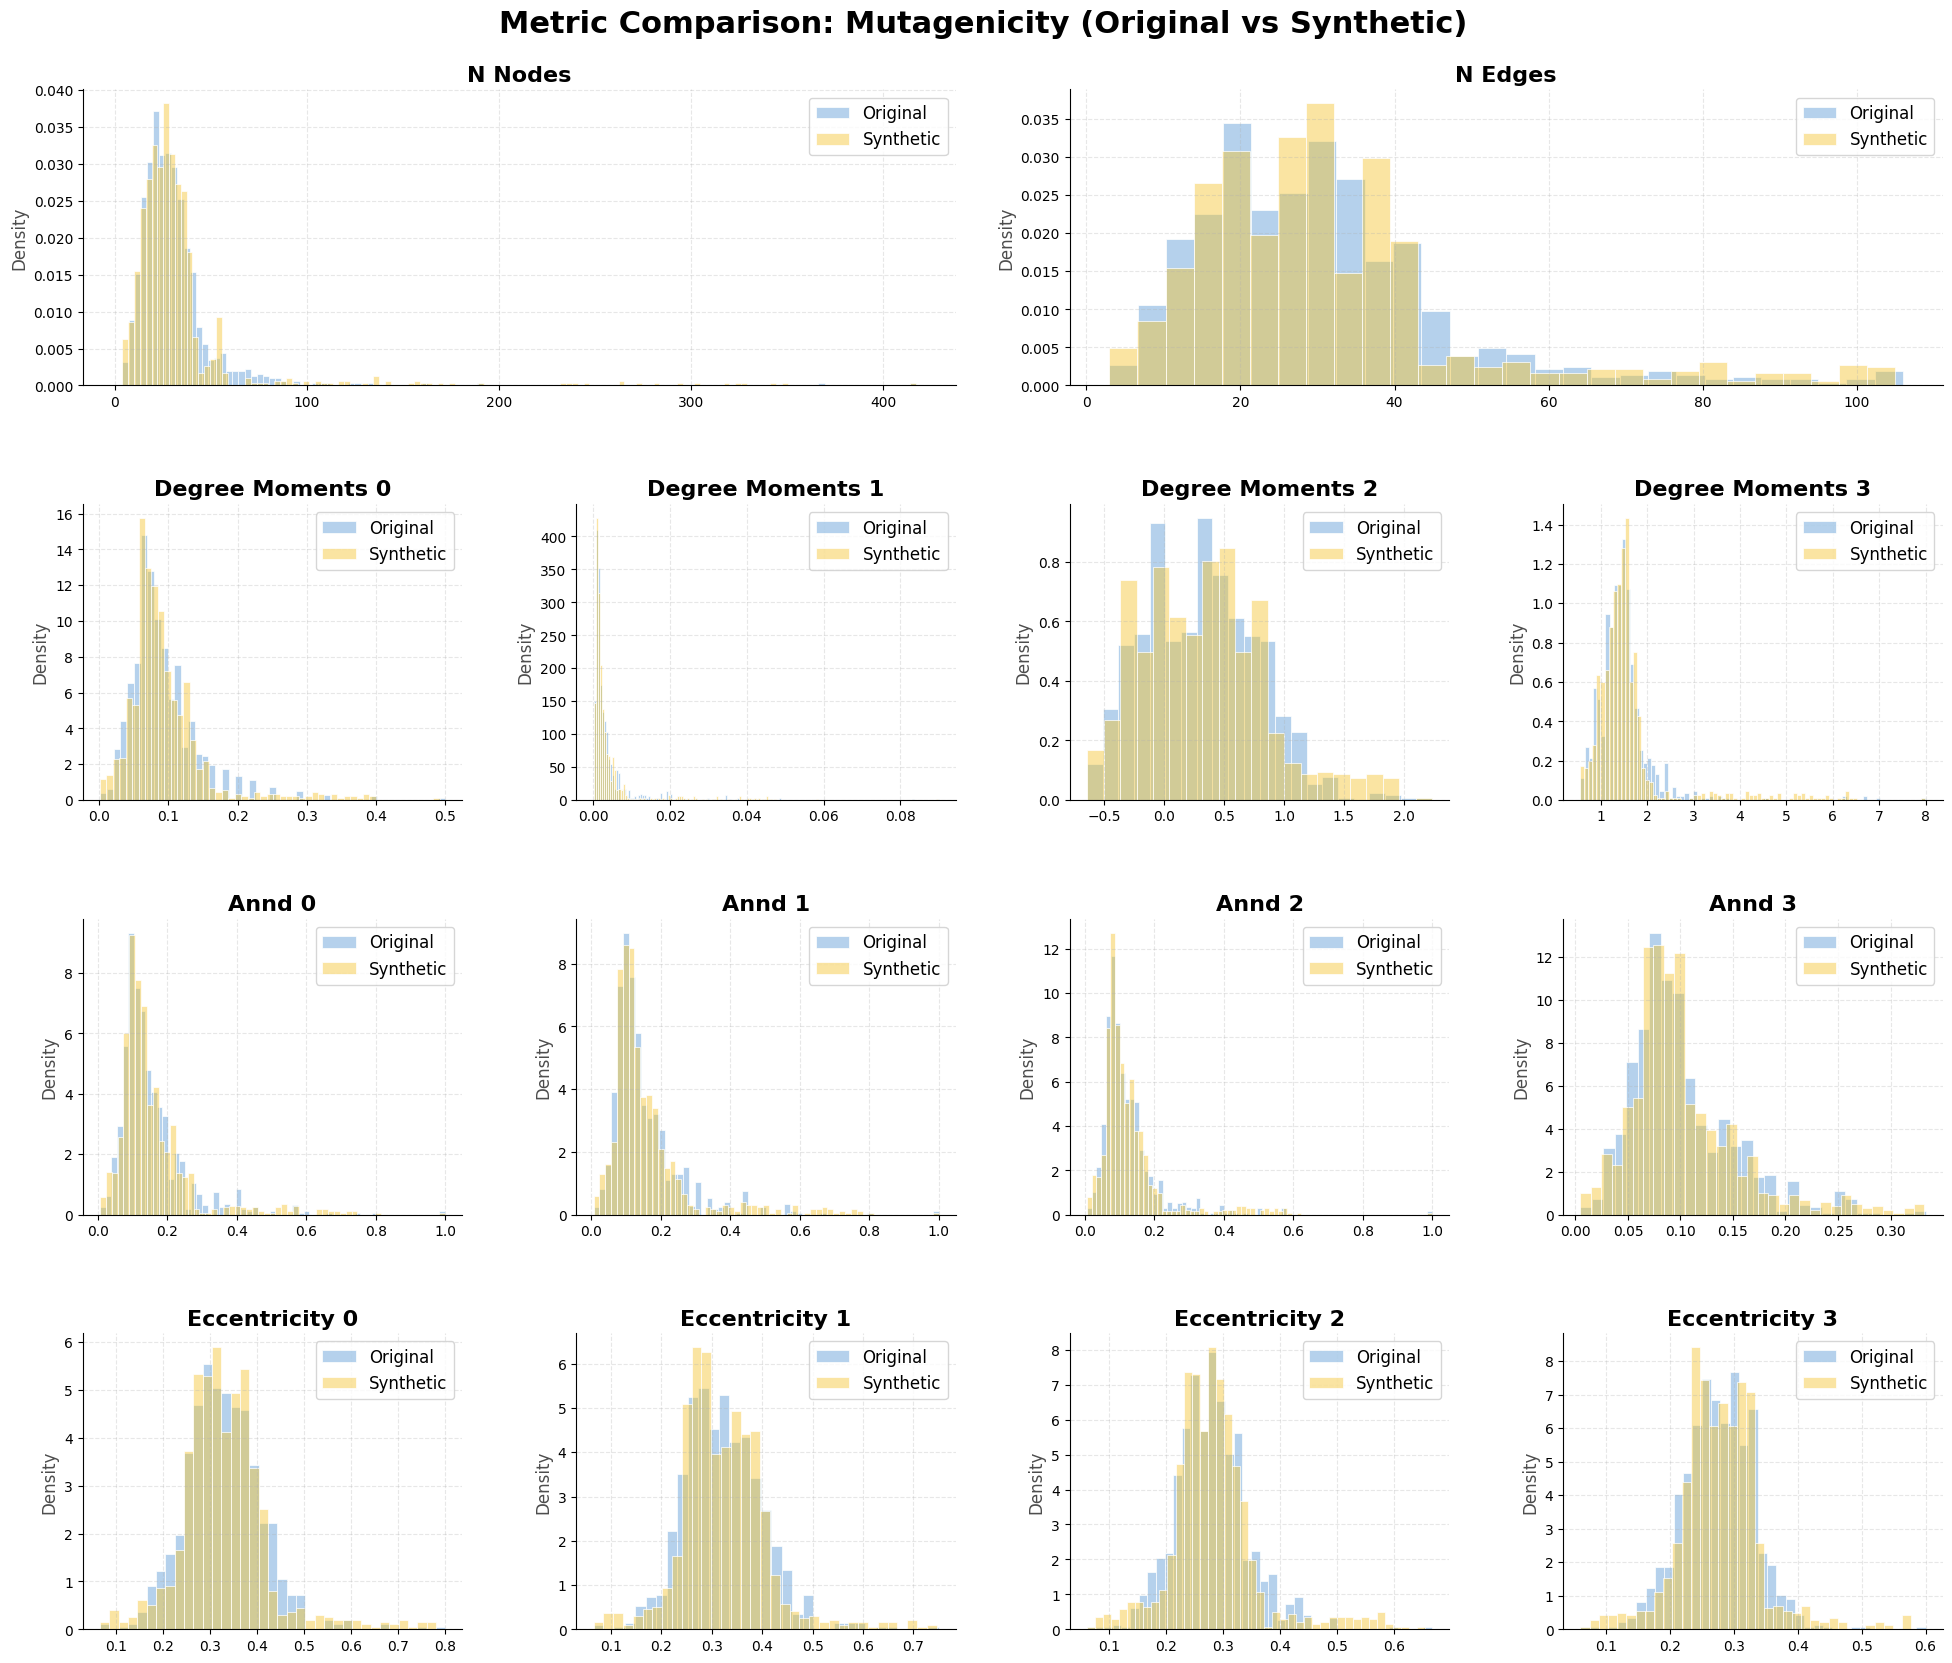

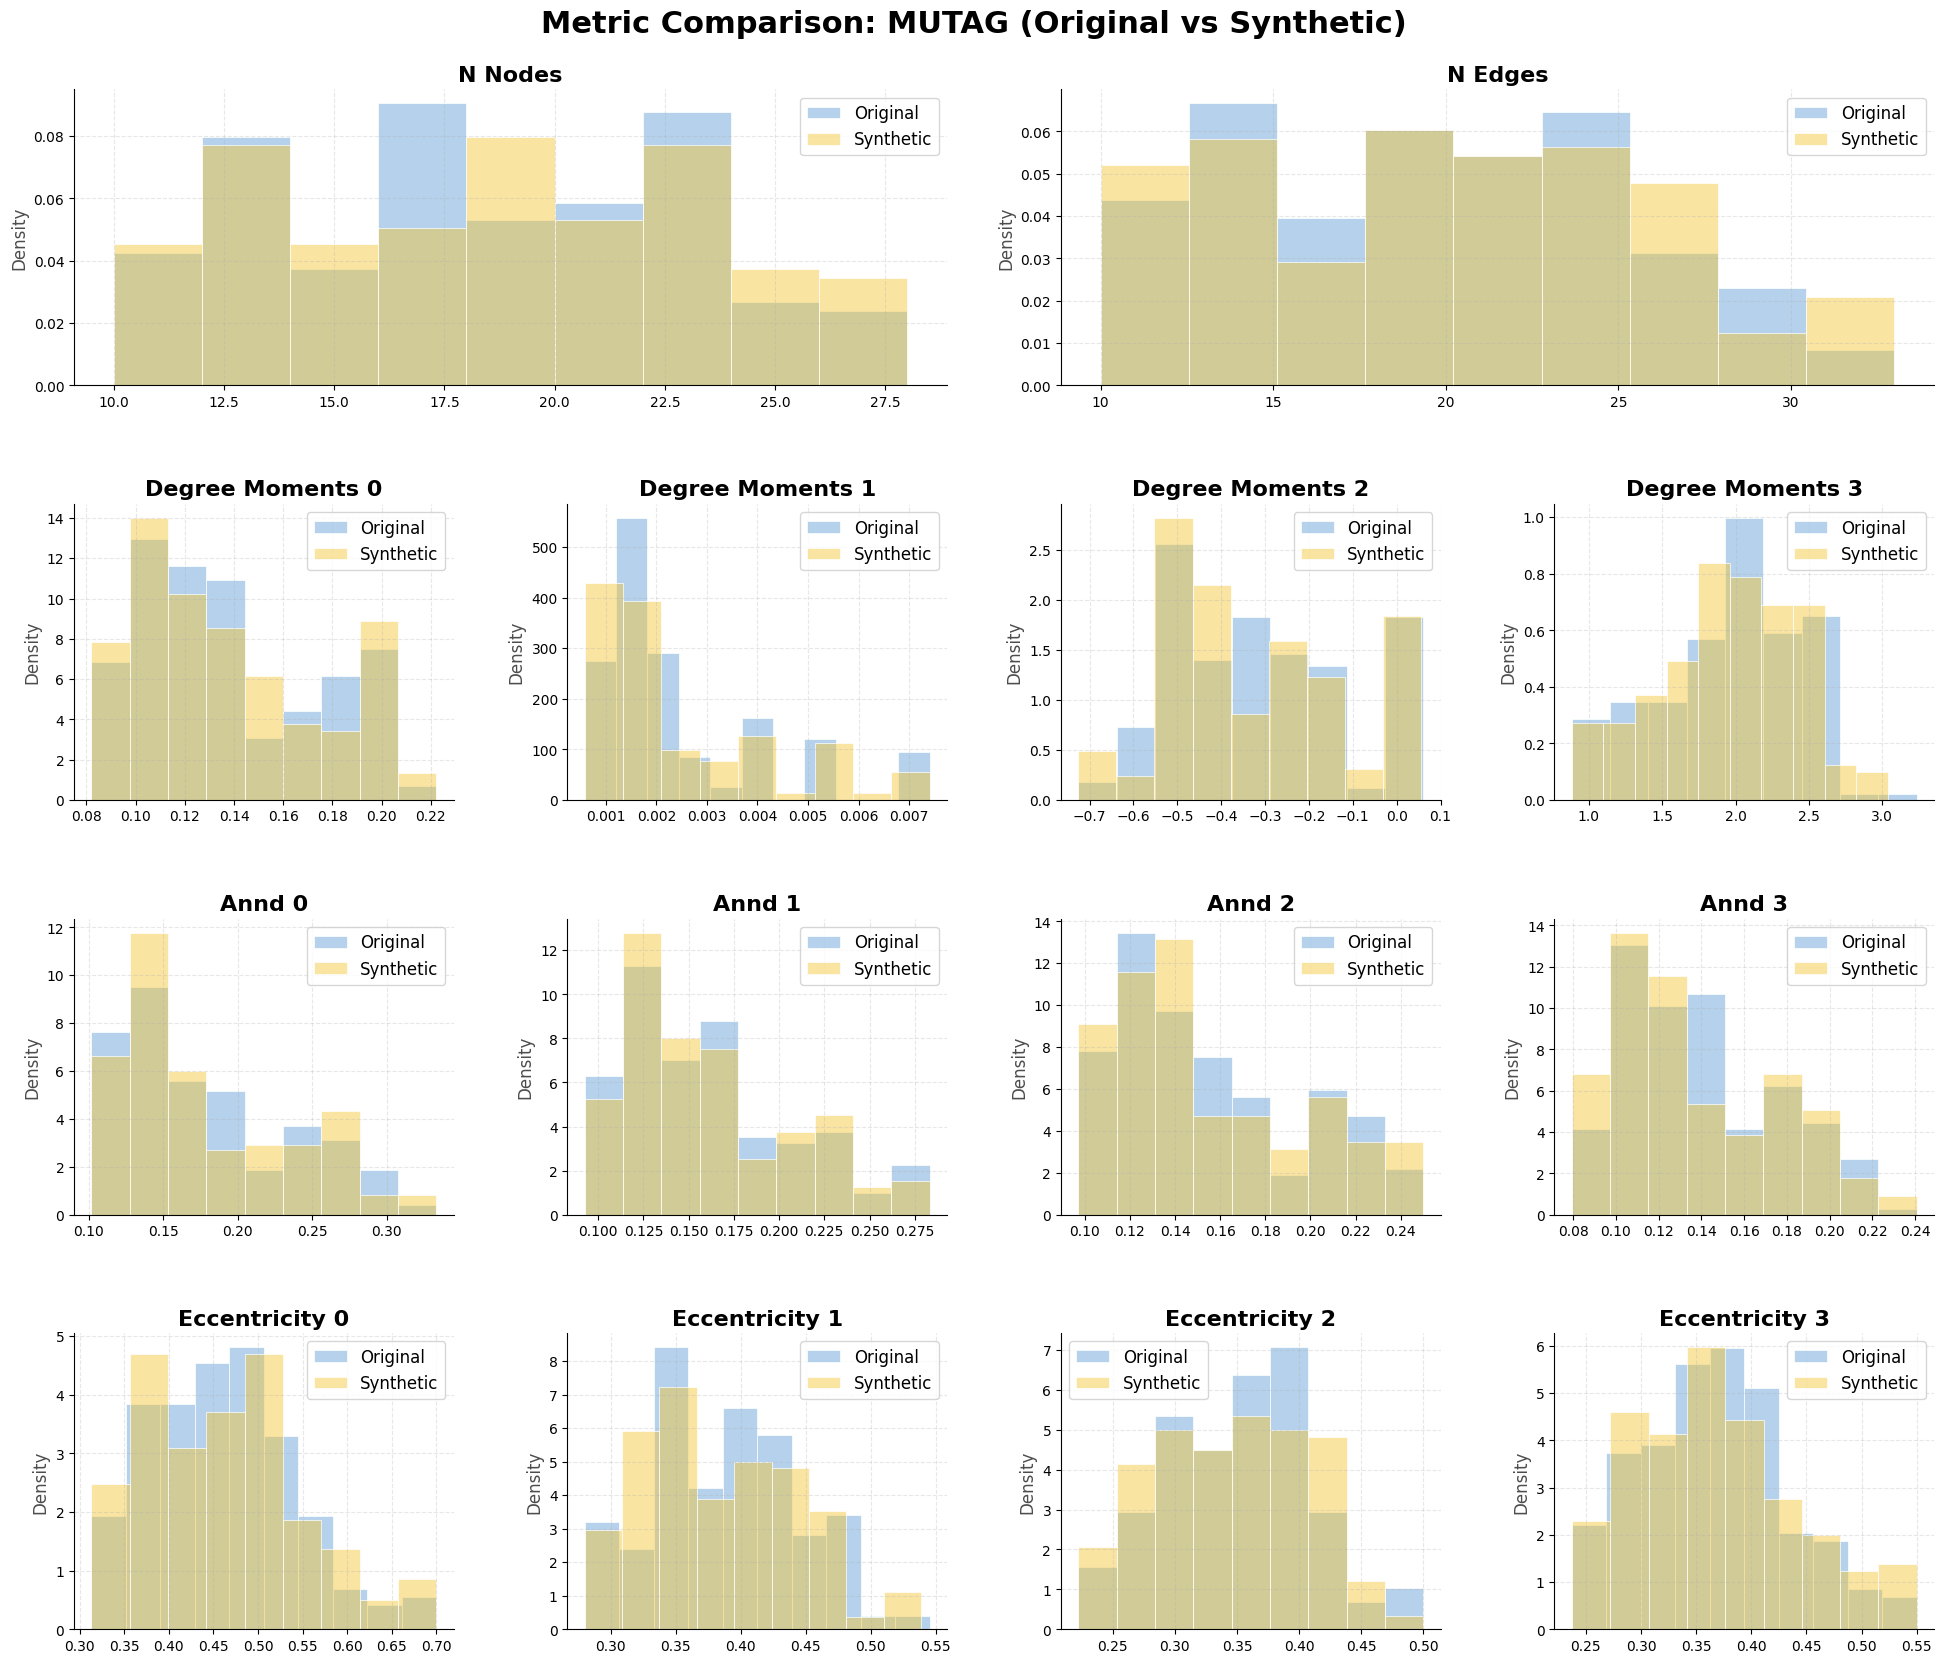


FINAL CONSOLIDATED SUMMARY (Mean Wasserstein Distances across all datasets)


,n_nodes,n_edges,degree_moments_0,degree_moments_1,degree_moments_2,degree_moments_3,annd_0,annd_1,annd_2,annd_3,eccentricity_0,eccentricity_1,eccentricity_2,eccentricity_3,GLOBAL_SCORE
Dataset,,,,,,,,,,,,,,,
BZR,0.015208,0.012924,0.010209,0.005129,0.028096,0.013557,0.008948,0.006807,0.008526,0.011637,0.012803,0.010314,0.016210,0.013539,0.012422
DHFR,0.011386,0.011345,0.008378,0.008964,0.015953,0.012466,0.009223,0.007841,0.008594,0.007968,0.014183,0.012330,0.013622,0.014205,0.011176
Mutagenicity,0.011324,0.011544,0.009615,0.009829,0.013777,0.018332,0.008427,0.012524,0.008608,0.010533,0.011900,0.010761,0.014831,0.011955,0.011711
MUTAG,0.019208,0.020120,0.021194,0.018263,0.021838,0.023739,0.019550,0.013956,0.017805,0.027261,0.021183,0.028497,0.027467,0.023108,0.021656
MEAN,0.014282,0.013983,0.012349,0.010546,0.019916,0.017023,0.011537,0.010282,0.010883,0.014350,0.015017,0.015475,0.018032,0.015702,0.014241



>>> FINAL PERFORMANCE (Average Global Score): 0.0142 <<<


In [4]:
def plot_dataset_comparison(df_orig: pd.DataFrame, df_synth: pd.DataFrame, dataset_name: str) -> None:
    """Plots distributions of all metrics for original vs synthetic datasets."""
    n_rows = 4  # 1 row for discrete + rows for continuous
    
    fig = plt.figure(figsize=(24, 5 * n_rows))
    fig.suptitle(f"Metric Comparison: {dataset_name} (Original vs Synthetic)", fontsize=22, fontweight="bold", y=0.92)
    gs = fig.add_gridspec(n_rows, 4, hspace=0.4, wspace=0.3)
    
    # Define mapping of feature to subplot
    metrics_map = []
    # Row 0: Discrete features (spanning 2 columns each)
    metrics_map.append((DISCRETE_FEATURES[0], fig.add_subplot(gs[0, :2])))
    metrics_map.append((DISCRETE_FEATURES[1], fig.add_subplot(gs[0, 2:])))    
    # Rows 1+: Continuous features (4 per row)
    for i, feat in enumerate(CONTINUOUS_FEATURES):
        row, col = divmod(i, 4)
        metrics_map.append((feat, fig.add_subplot(gs[row + 1, col])))
        
    for feat, ax in metrics_map:
        if feat not in df_orig.columns:
            ax.axis("off")
            continue
            
        # Plot distributions
        for data, label, color in [(df_orig, "Original", "#5B9BD5"), (df_synth, "Synthetic", "#F5C431")]:
            sns.histplot(
                data=data, x=feat, ax=ax, label=label,
                color=color, alpha=0.45, stat="density", element="bars",
                linewidth=0.5, edgecolor="white"
            )
        
        ax.set_title(feat.replace("_", " ").title(), fontsize=16, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Density", fontsize=12, alpha=0.7)
        ax.legend(fontsize=12, frameon=True, facecolor="white", framealpha=0.8)
        ax.grid(True, linestyle="--", alpha=0.3)
        sns.despine(ax=ax)
        
    plt.show()

def compute_wassestrain_distance(df_orig: pd.DataFrame, df_synth: pd.DataFrame) -> dict:
    """Computes the Wasserstein distance for each feature using anchored Min-Max scaling.
    
    Args:
        df_orig: Original dataset DataFrame
        df_synth: Synthetic dataset DataFrame
    Returns:
        Dictionary mapping feature names to their Wasserstein distance
    """
    results = {}
    for feat in FEATURES:
        if feat not in df_orig.columns or feat not in df_synth.columns:
            raise ValueError(f"Feature {feat} not found in both datasets.")
            
        orig_values = df_orig[feat].values
        synth_values = df_synth[feat].values
        
        # 1. Anchored Min-Max Scaling
        min_val = np.min(orig_values)
        max_val = np.max(orig_values)
        range_val = max_val - min_val
        
        if range_val > 0:
            orig_scaled = (orig_values - min_val) / range_val
            synth_scaled = (synth_values - min_val) / range_val
        else:
            orig_scaled = orig_values - min_val
            synth_scaled = synth_values - min_val
            
        # 2. Wasserstein Distance calculation
        dist = wasserstein_distance(orig_scaled, synth_scaled)
        results[feat] = dist
        
    return results


all_distances_results = []

for dataset_name in DATASETS:
    df_orig = df[df["dataset"] == dataset_name]
    df_synth = df_synthetic[df_synthetic["dataset"] == dataset_name]
    
    # Visualization
    plot_dataset_comparison(df_orig, df_synth, dataset_name)
    
    # Statistical Evaluation
    distances = compute_wassestrain_distance(df_orig, df_synth)
    global_score = np.mean(list(distances.values()))
    
    # Store results
    res_row = {"Dataset": dataset_name}
    res_row.update(distances)
    res_row["GLOBAL_SCORE"] = global_score
    all_distances_results.append(res_row)
    
# Final Summary Aggregation
print("\n" + "="*100)
print("FINAL CONSOLIDATED SUMMARY (Mean Wasserstein Distances across all datasets)")
print("="*100)

df_summary = pd.DataFrame(all_distances_results).set_index("Dataset")
# Add a "MEAN" row to aggregate results across all datasets
df_summary.loc["MEAN"] = df_summary.mean()

display(df_summary)

final_avg_global = df_summary.loc["MEAN", "GLOBAL_SCORE"]
print(f"\n>>> FINAL PERFORMANCE (Average Global Score): {final_avg_global:.4f} <<<")

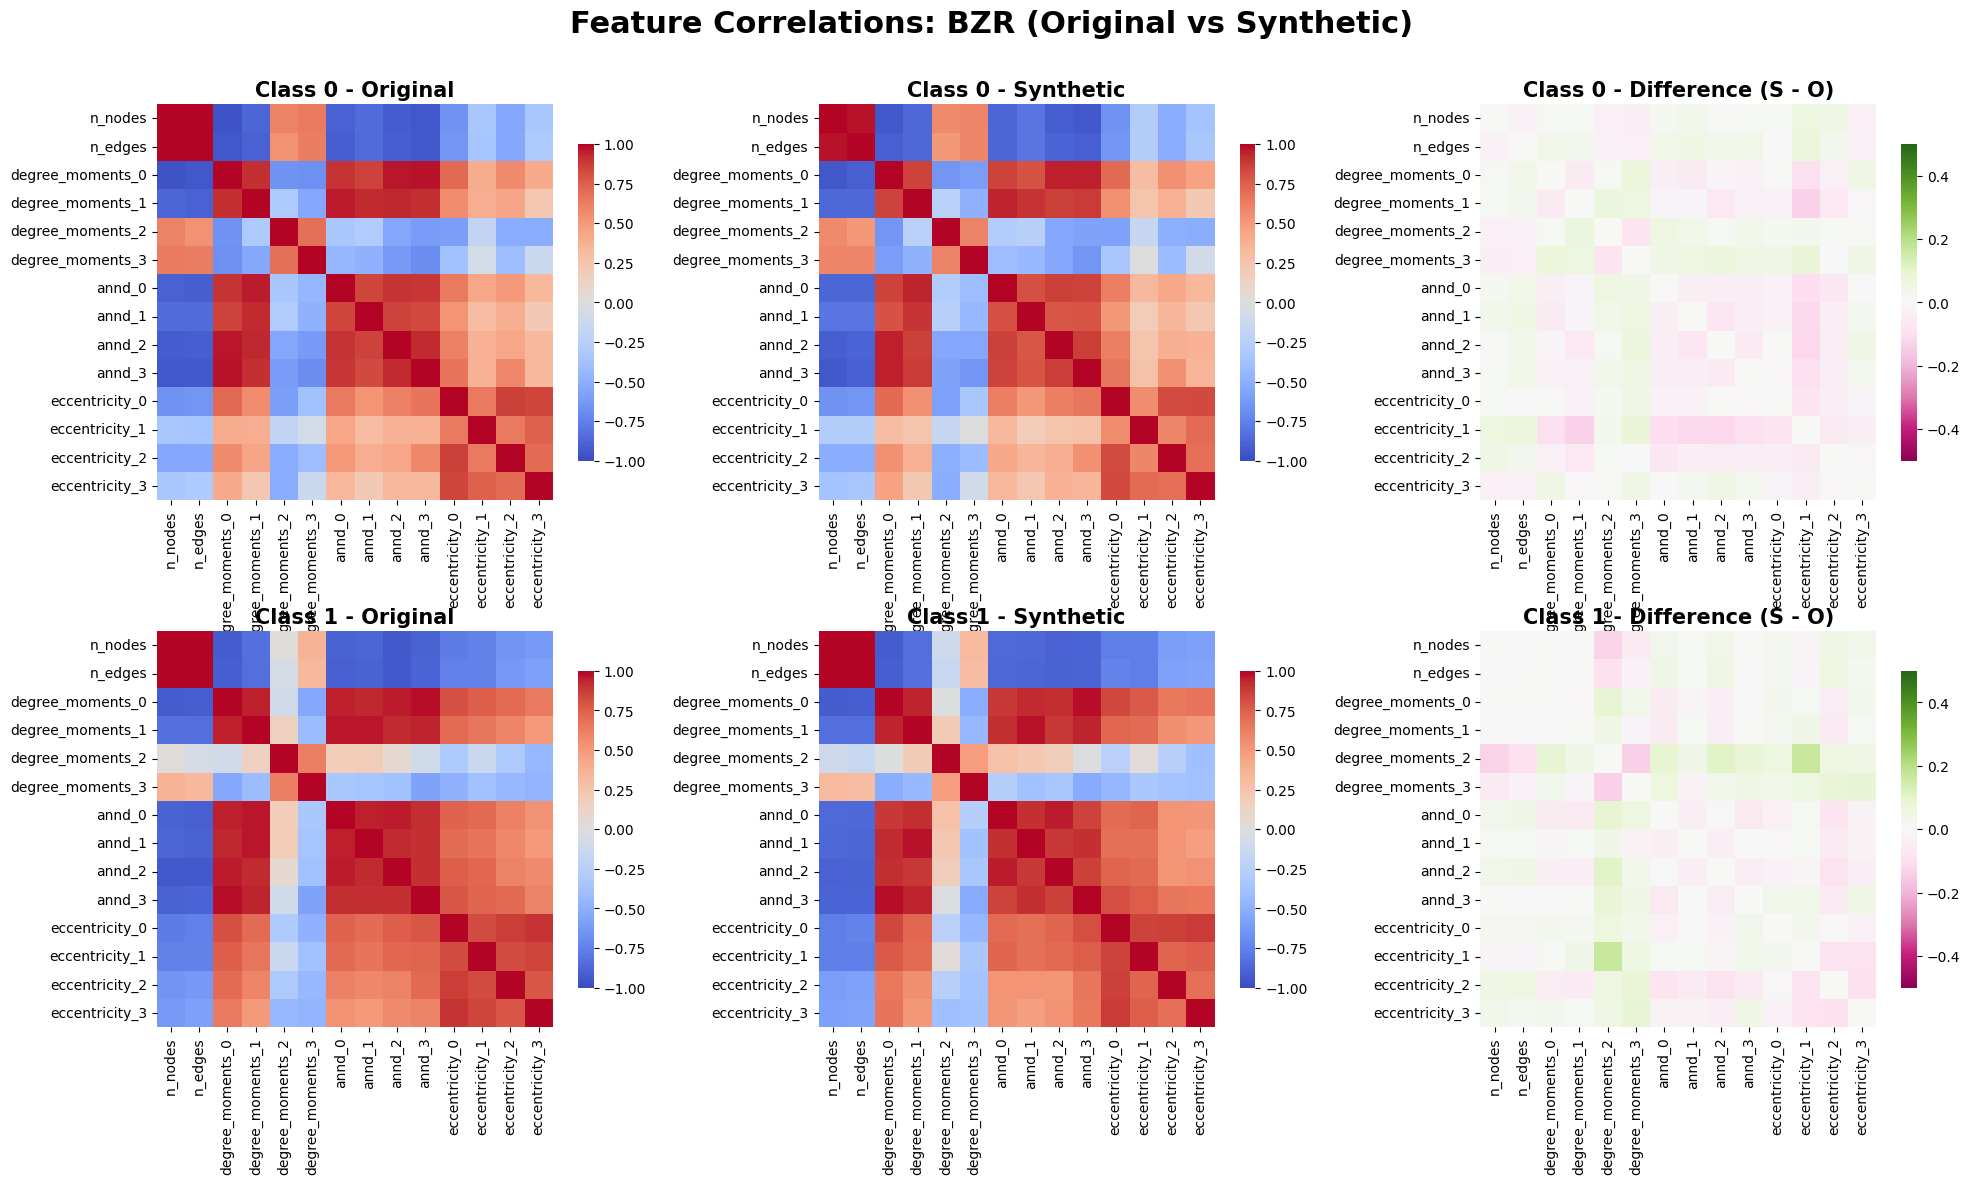

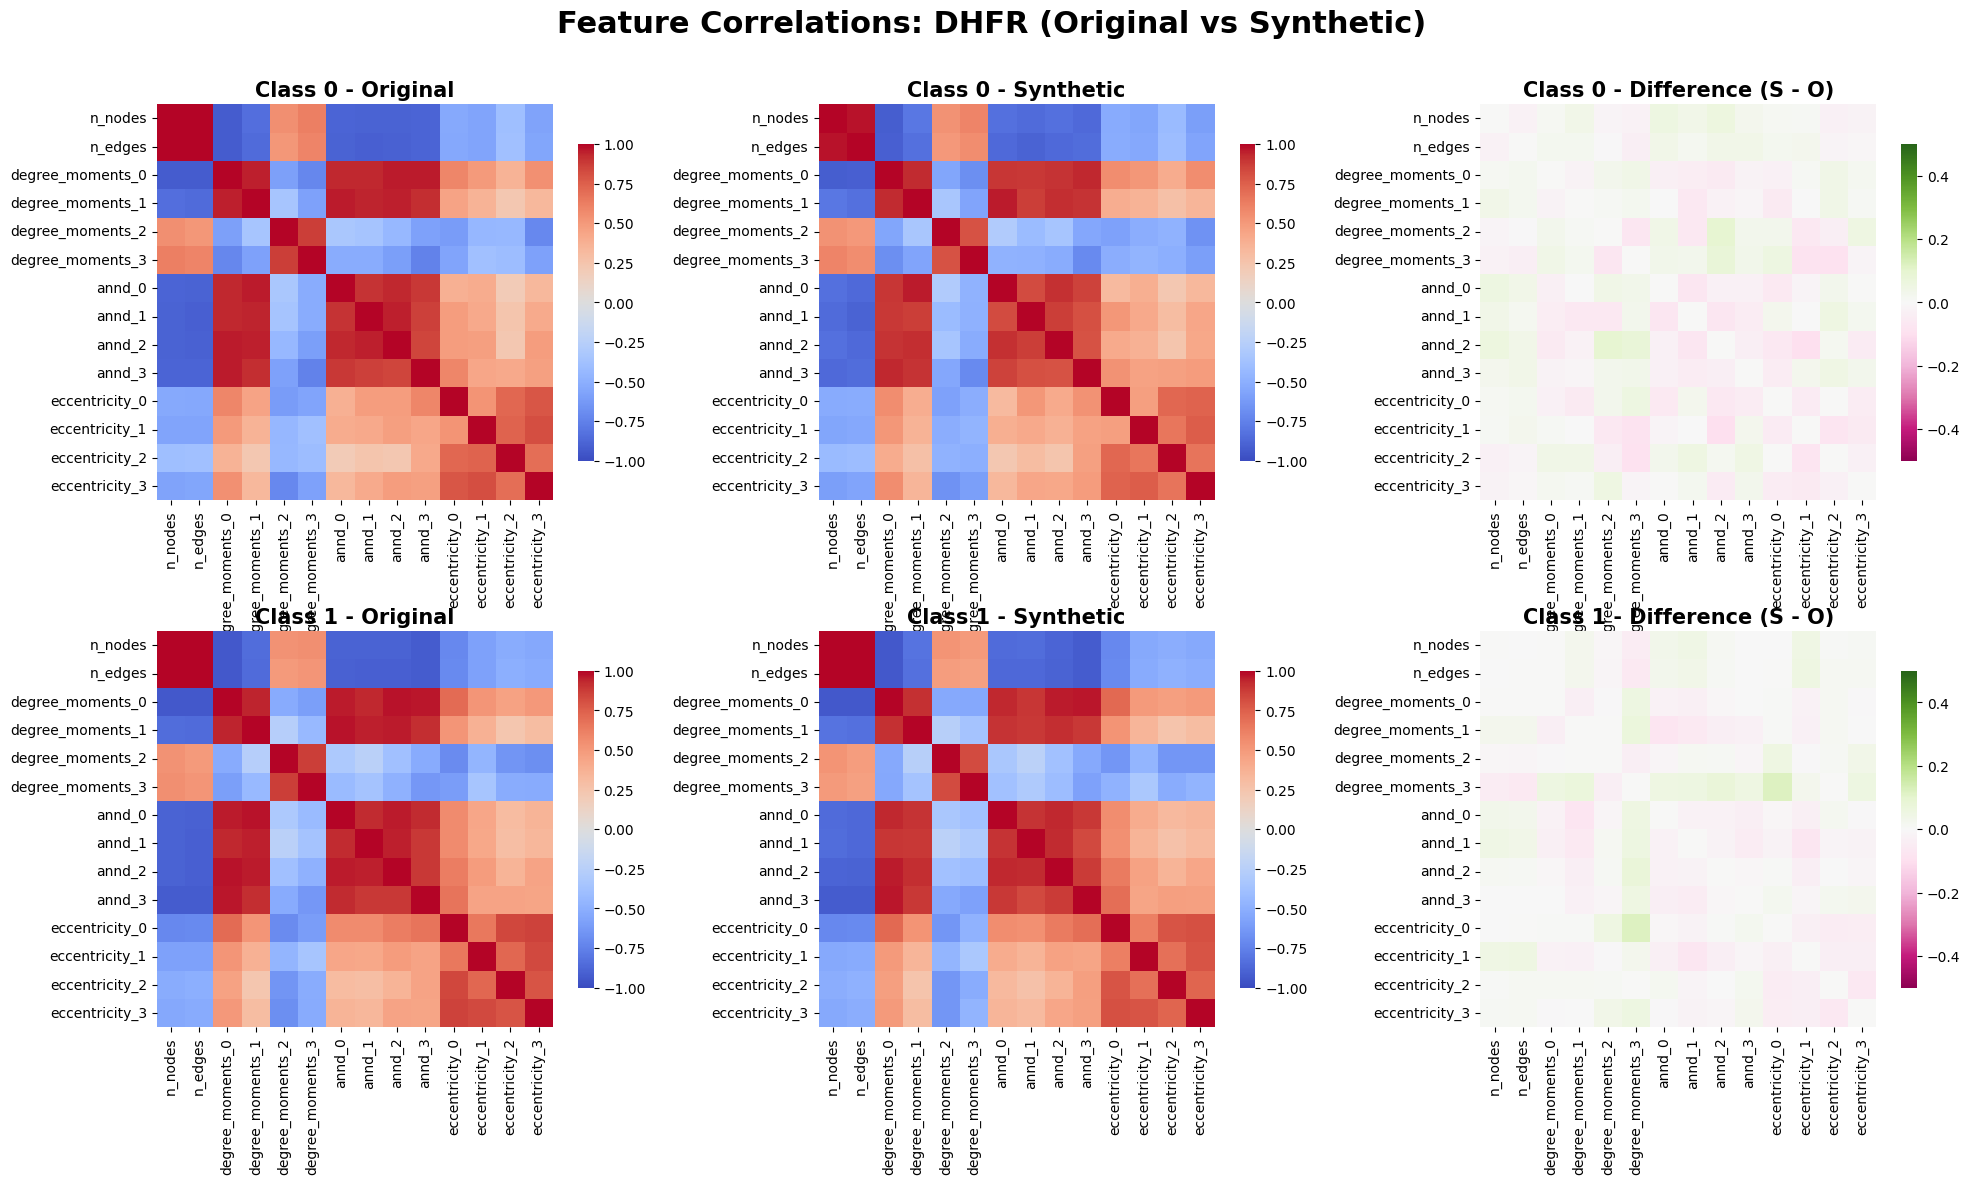

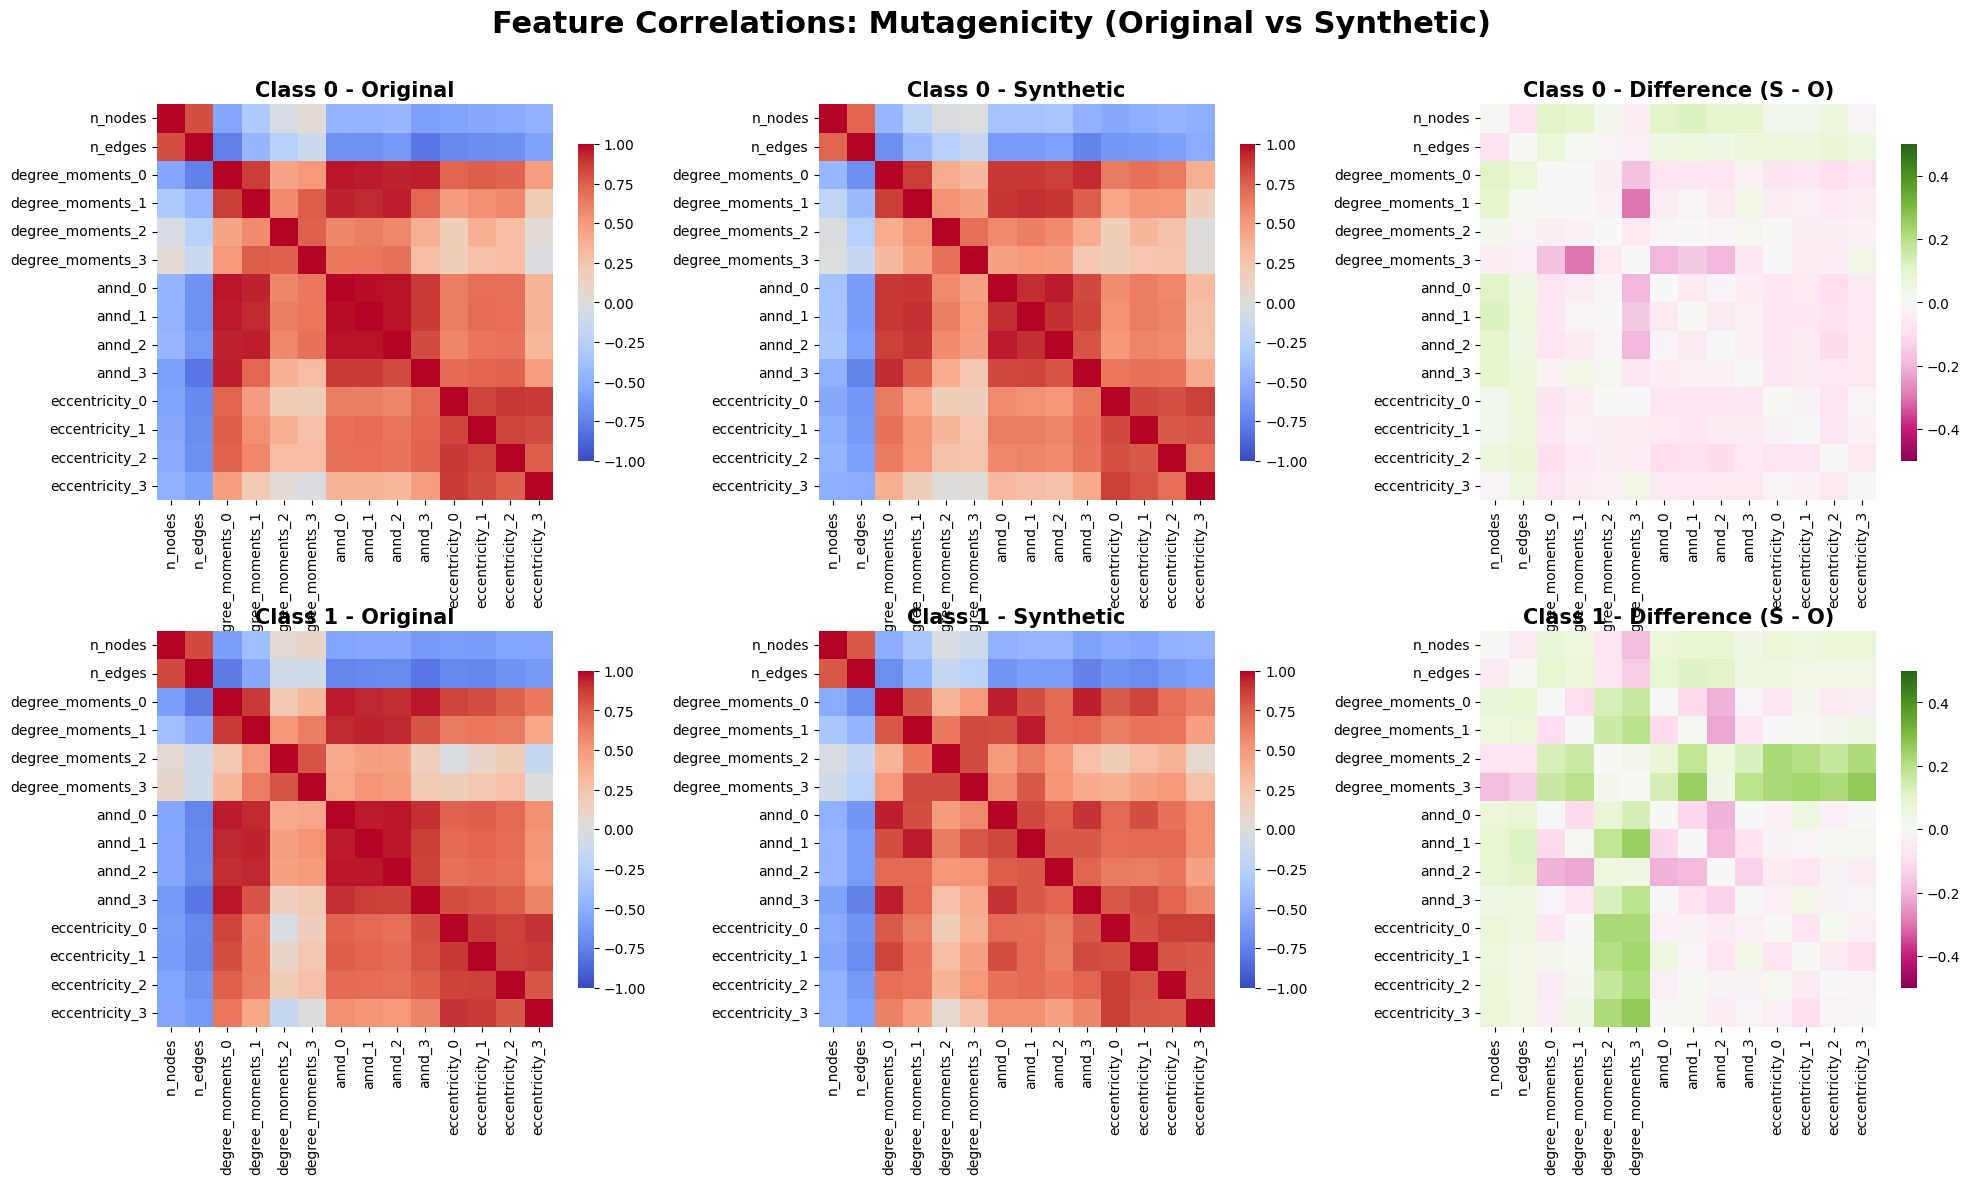

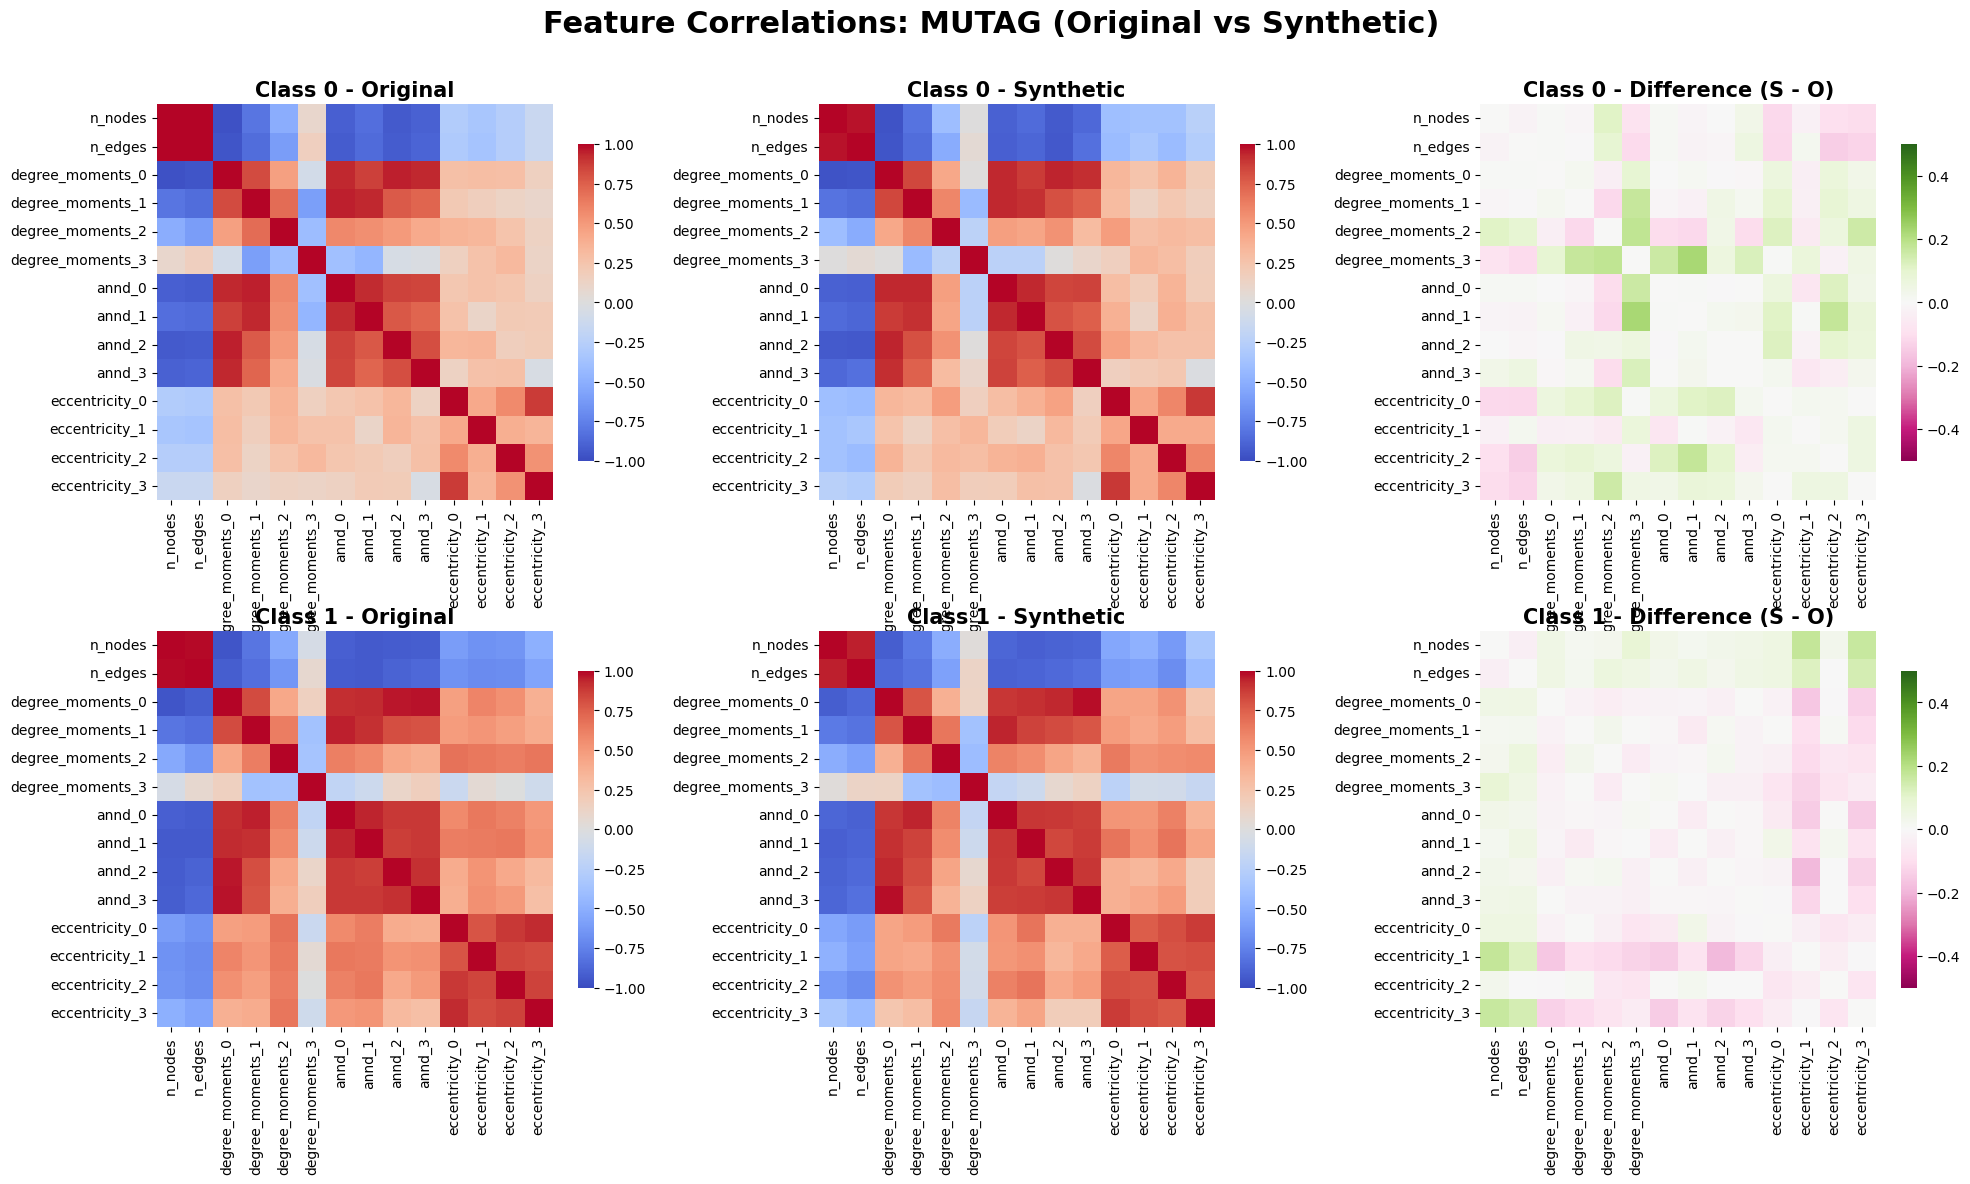


FINAL CORRELATION FIDELITY SUMMARY (Mean Absolute Error)


,Correlation_MAE
Dataset,
BZR,0.037714
DHFR,0.029623
Mutagenicity,0.070409
MUTAG,0.051940
MEAN,0.047422



>>> FINAL CORRELATION PERFORMANCE (Average MAE): 0.0474 <<<


In [5]:
def plot_correlation_matrix(df_orig: pd.DataFrame, df_synth: pd.DataFrame, dataset_name: str) -> list[np.ndarray]:
    """Plots correlation heatmaps between original and synthetic metrics for each class.
    
    Args:
        df_orig: Original dataset DataFrame
        df_synth: Synthetic dataset DataFrame
        dataset_name: Name of the dataset
    Returns:
        List of correlation difference matrices (one per class)
    """
    classes = sorted(df_orig["class_id"].unique())
    n_classes = len(classes)
    
    fig, axes = plt.subplots(n_classes, 3, figsize=(20, 6 * n_classes))
    if n_classes == 1:
        axes = axes.reshape(1, 3)
        
    fig.suptitle(f"Feature Correlations: {dataset_name} (Original vs Synthetic)", fontsize=22, fontweight="bold", y=0.99)
    
    diff_matrices = []
    
    for i, class_id in enumerate(classes):
        # Filter by class
        orig_cls = df_orig[df_orig["class_id"] == class_id][FEATURES]
        synth_cls = df_synth[df_synth["class_id"] == class_id][FEATURES]
        
        # Calculate Pearson correlations
        corr_orig = orig_cls.corr().fillna(0)
        corr_synth = synth_cls.corr().fillna(0)
        corr_diff = corr_synth - corr_orig
        
        diff_matrices.append(corr_diff.values)
        
        # Heatmap styling
        heatmap_kwargs = {
            "center": 0,
            "annot": False,
            "square": True,
            "cbar_kws": {"shrink": 0.8}
        }
        
        # 1. Original Matrix
        sns.heatmap(corr_orig, ax=axes[i, 0], cmap="coolwarm", vmin=-1, vmax=1, **heatmap_kwargs)
        axes[i, 0].set_title(f"Class {class_id} - Original", fontsize=15, fontweight="bold")
        
        # 2. Synthetic Matrix
        sns.heatmap(corr_synth, ax=axes[i, 1], cmap="coolwarm", vmin=-1, vmax=1, **heatmap_kwargs)
        axes[i, 1].set_title(f"Class {class_id} - Synthetic", fontsize=15, fontweight="bold")
        
        # 3. Difference Matrix (Synthetic - Original)
        # Use a different colormap to highlight discrepancies
        sns.heatmap(corr_diff, ax=axes[i, 2], cmap="PiYG", vmin=-0.5, vmax=0.5, **heatmap_kwargs)
        axes[i, 2].set_title(f"Class {class_id} - Difference (S - O)", fontsize=15, fontweight="bold")

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()
    
    return diff_matrices


all_corr_errors = []

for dataset_name in DATASETS:
    df_orig = df[df["dataset"] == dataset_name]
    df_synth = df_synthetic[df_synthetic["dataset"] == dataset_name]
    
    # Correlation Analysis
    diff_mats = plot_correlation_matrix(df_orig, df_synth, dataset_name)
    
    # Compute global correlation error
    avg_corr_err = np.mean([np.abs(m).mean() for m in diff_mats])
    all_corr_errors.append({"Dataset": dataset_name, "Correlation_MAE": avg_corr_err})

# Final Correlation Summary Table
print("\n" + "="*100)
print("FINAL CORRELATION FIDELITY SUMMARY (Mean Absolute Error)")
print("="*100)
df_corr_summary = pd.DataFrame(all_corr_errors).set_index("Dataset")
df_corr_summary.loc["MEAN"] = df_corr_summary.mean()

display(df_corr_summary)

final_avg_corr = df_corr_summary.loc["MEAN", "Correlation_MAE"]
print(f"\n>>> FINAL CORRELATION PERFORMANCE (Average MAE): {final_avg_corr:.4f} <<<")

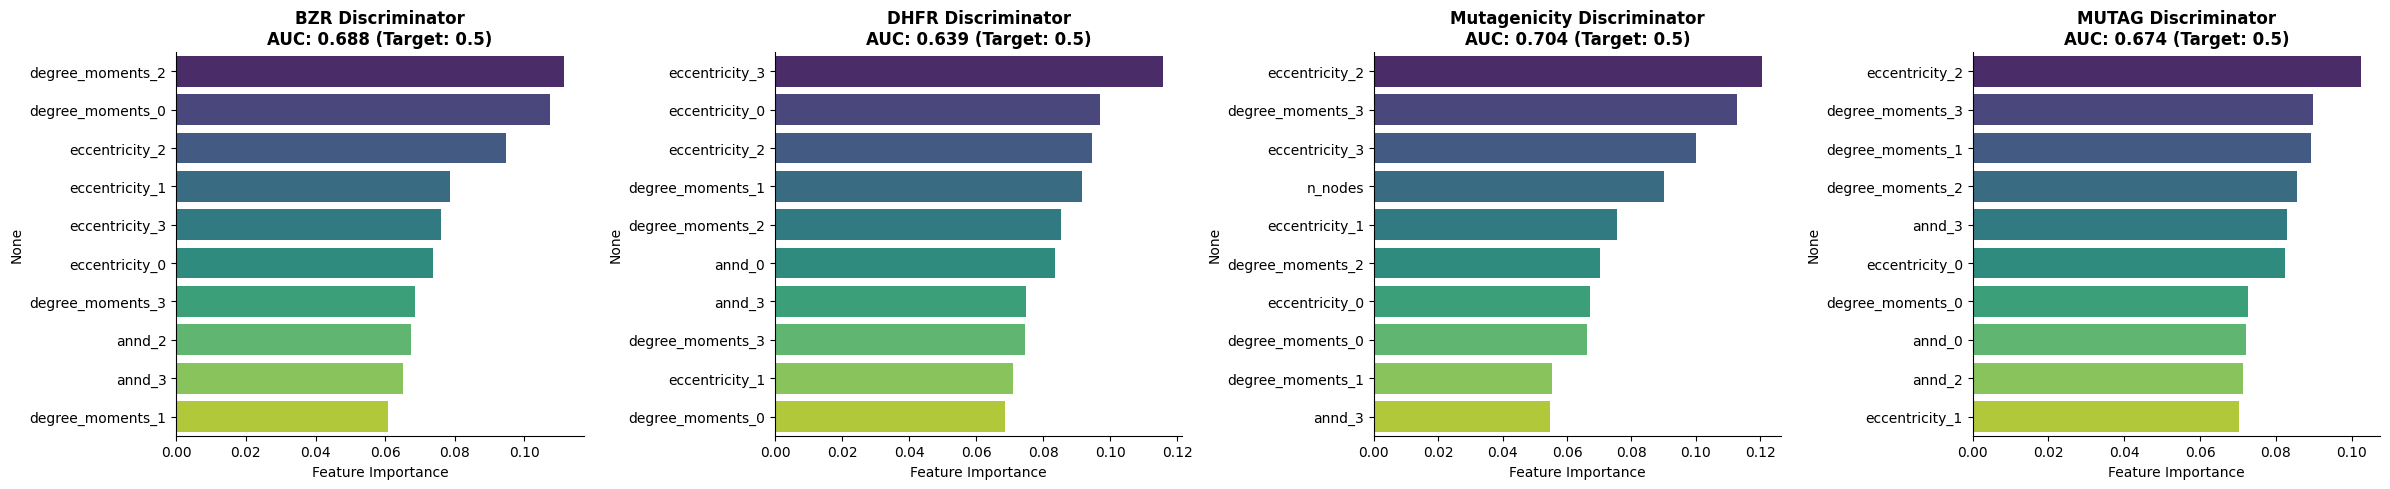

,Discriminator_AUC,Discriminator_Accuracy,Top_Giveaway_Feature
Dataset,,,
BZR,0.688389,0.613169,degree_moments_2
DHFR,0.638534,0.599119,eccentricity_3
Mutagenicity,0.704339,0.646667,eccentricity_2
MUTAG,0.673872,0.654867,eccentricity_2
MEAN,0.676283,0.628455,NaN



>>> FINAL DISCRIMINATOR AUC: 0.6763 (Closer to 0.5 is better) <<<


In [6]:
def run_adversarial_check(df_orig: pd.DataFrame, df_synth: pd.DataFrame, dataset_name: str, ax=None) -> dict:
    """Trains a discriminator to distinguish between real and synthetic data."""
    
    # Assign label 0 to original, 1 to synthetic
    df_orig_eval = df_orig[FEATURES].copy()
    df_orig_eval["is_synthetic"] = 0
    df_synth_eval = df_synth[FEATURES].copy()
    df_synth_eval["is_synthetic"] = 1
    
    # Combine datasets
    df_eval = pd.concat([df_orig_eval, df_synth_eval], ignore_index=True)
    X = df_eval[FEATURES]
    y = df_eval["is_synthetic"]
    
    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    
    # Train Discriminator
    classifier = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
    classifier.fit(X_train, y_train)
    
    # Predict and Evaluate
    y_pred_proba = classifier.predict_proba(X_test)[:, 1]
    y_pred = classifier.predict(X_test)
    
    auc_score = roc_auc_score(y_test, y_pred_proba)
    acc_score = accuracy_score(y_test, y_pred)
    
    # Extract Feature Importance
    importances = pd.Series(classifier.feature_importances_, index=FEATURES).sort_values(ascending=False)
    
    # Plotting Feature Importance if an axis is provided
    if ax is not None:
        sns.barplot(x=importances.values[:10], y=importances.index[:10], ax=ax, palette="viridis", hue=importances.index[:10])
        ax.set_title(f"{dataset_name} Discriminator\nAUC: {auc_score:.3f} (Target: 0.5)", fontweight="bold")
        ax.set_xlabel("Feature Importance")
        sns.despine(ax=ax)
        
    return {
        "Dataset": dataset_name,
        "Discriminator_AUC": auc_score,
        "Discriminator_Accuracy": acc_score,
        "Top_Giveaway_Feature": importances.index[0]
    }

all_adversarial_results = []
fig, axes = plt.subplots(1, len(DATASETS), figsize=(6 * len(DATASETS), 5))
if len(DATASETS) == 1: axes = [axes]

for i, dataset_name in enumerate(DATASETS):
    df_o = df[df["dataset"] == dataset_name]
    df_s = df_synthetic[df_synthetic["dataset"] == dataset_name]
    
    res = run_adversarial_check(df_o, df_s, dataset_name, ax=axes[i])
    all_adversarial_results.append(res)

plt.tight_layout()
plt.show()

# Final Summary Table
df_adv_summary = pd.DataFrame(all_adversarial_results).set_index("Dataset")
df_adv_summary.loc["MEAN"] = df_adv_summary[["Discriminator_AUC", "Discriminator_Accuracy"]].mean()

display(df_adv_summary)

final_avg_auc = df_adv_summary.loc["MEAN", "Discriminator_AUC"]
print(f"\n>>> FINAL DISCRIMINATOR AUC: {final_avg_auc:.4f} (Closer to 0.5 is better) <<<")